In [1]:
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
from astropy.time import Time
from datetime import datetime
import pickle, json, sys, os, glob, subprocess, tables
from scipy.optimize import curve_fit
from scipy.stats import chi2
import pandas as pd
pd.set_option("display.max_columns", None)

sys.path.insert(0, os.getcwd() + "/../scripts/")
import auxiliar as aux
import geometry as geom
import plotting

In [46]:
# Root path of this script
root = os.getcwd() + "/"
# Objects directory
root_data = root + "../data/"

# LST run numbers
obs_ids = [*np.arange(19799, 19811 + 1), *np.arange(17820, 17825 + 1)]# np.arange(19799, 19811 + 1) # np.arange(17820, 17825 + 1)
obs_ids = [3954, 3955, 3956]
# obs_ids = [4007, 4008]

# Parameters for parameter ZD corrections ----------
p0a, p0b, p0c = -0.44751321, 3.62502037, -1.43611437
p1a, p1b, p1c = -2.89253919, 0.99443581, -0.34013068
# Reference values (good period)
ref_p0 =  1.74 
ref_p1 = -2.23

limits_intensity = [316, 562]

ref_intensity = 422

In [47]:
%%time
files_dl1_srun, files_dl1 = [], []
for obs_id in obs_ids:
    query_dl1_srun = np.sort(glob.glob(
        f"/fefs/aswg/data/real/DL1/????????/v*/tailcut*/dl1_LST-1.Run{obs_id:05}.????.h5"
    ))
    query_dl1 = np.sort(glob.glob(
        f"/fefs/aswg/data/real/DL1/????????/v*/tailcut*/dl1_LST-1.Run{obs_id:05}.h5"
    ))
    
    files_dl1_srun.append(query_dl1_srun)
    files_dl1.append(query_dl1[0])
    
bin_edges = np.logspace(1, 6, 101)
bin_c = (bin_edges[1:] + bin_edges[:-1]) / 2
bin_w = np.diff(bin_edges)

mask_dcheck_bins_fit = (
    (bin_c >= limits_intensity[0]) &
    (bin_c <= limits_intensity[1])
)

CPU times: user 4.92 s, sys: 3.25 s, total: 8.17 s
Wall time: 9.39 s


In [48]:
%%time
dict_data = {
    "rates": [], "u_rates": [], "tspan": [], "tstamp": [], "zd": [],
    "p0": [[] for _ in obs_ids], "u_p0": [[] for _ in obs_ids],
    "p0_c": [[] for _ in obs_ids], "u_p0_c": [[] for _ in obs_ids],
    "p1": [[] for _ in obs_ids], "u_p1": [[] for _ in obs_ids],
    "p1_c": [[] for _ in obs_ids], "u_p1_c": [[] for _ in obs_ids],
    "fit_pvalue": [[] for _ in obs_ids], "fit_chi2": [[] for _ in obs_ids],
    "ly": [[] for _ in obs_ids], "u_ly": [[] for _ in obs_ids],
    "ly_c": [[] for _ in obs_ids], "u_ly_c": [[] for _ in obs_ids]
}

for j, file in enumerate(files_dl1):
    print(f"Computing intensity parameters for Run {obs_ids[j]}, {j+1} / {len(obs_ids)}")

    # Checking if the file exists already
    if os.path.exists(f"tmp/intensity_runs/data_Run{obs_ids[j]}.npz"):
        print(f"Run {obs_ids[j]} already processed, reading...\n")

        # Loading the data
        with np.load(f"tmp/intensity_runs/data_Run{obs_ids[j]}.npz") as data:
            dict_data["rates"].append(data["rates"]); dict_data["u_rates"].append(data["u_rates"])
            dict_data["tspan"].append(data["tspan"]); dict_data["zd"].append(data["zd"])
            dict_data["tstamp"].append(data["tstamp"])
            dict_data["p0"][j] = data["p0"]; dict_data["u_p0"][j] = data["u_p0"]
            dict_data["p0_c"][j] = data["p0_c"]; dict_data["u_p0_c"][j] = data["u_p0_c"]
            dict_data["p1"][j] = data["p1"]; dict_data["u_p1"][j] = data["u_p1"]
            dict_data["p1_c"][j] = data["p1_c"]; dict_data["u_p1_c"][j] = data["u_p1_c"]
            dict_data["fit_pvalue"][j] = data["fit_pvalue"]; dict_data["fit_chi2"][j] = data["fit_chi2"]
            dict_data["ly"][j] = data["ly"]; dict_data["u_ly"][j] = data["u_ly"]
            
        continue
    
    intensity_srun, telapsed_srun, tstamp_srun, zd_srun = [], [], [], []
    for s, file_srun in enumerate(files_dl1_srun[j]):
        print(f"Computing Subrun {s} / {len(files_dl1_srun[j])}") if s % 15 == 0 else None
        tab = tables.open_file(file_srun).root.dl1.event.telescope.parameters.LST_LSTCam
        _intensity_srun, _ = np.histogram(
            tab.col("intensity"), 
            bins = bin_edges,
        )
        time = tab.col("dragon_time")
        zd_srun.append(np.mean(np.pi / 2 - tab.col("alt_tel")))
        tstamp_srun.append(time[0])
        tab.close()
        
        _telapsed_srun = time[-1] - time[0]
        intensity_srun.append(_intensity_srun)
        telapsed_srun.append(_telapsed_srun)
        
    dict_data["tspan"].append(np.array(telapsed_srun))
    dict_data["tstamp"].append(np.array(tstamp_srun))
    dict_data["zd"].append(np.array(zd_srun))
    
    _rates = [intensity_srun[i] / telapsed_srun[i] / bin_w for i in range(len(intensity_srun))]
    _u_rates = [np.sqrt(intensity_srun[i]) / telapsed_srun[i] / bin_w for i in range(len(intensity_srun))]    
    dict_data["rates"].append(np.array(_rates)); dict_data["u_rates"].append(np.array(_u_rates))
    
    for s in range(len(_rates)):
        print(f"Fitting {s} / {len(telapsed_srun)}") if s % 45 == 0 else None
        
        x_fit = bin_c[mask_dcheck_bins_fit] / ref_intensity
        y_fit = _rates[s][mask_dcheck_bins_fit]
        yerr_fit = _u_rates[s][mask_dcheck_bins_fit]

        params, pcov, info, _, _ = curve_fit(
            f     = geom.powerlaw,
            xdata = x_fit,
            ydata = y_fit,
            sigma = yerr_fit,
            p0    = [ref_p0, ref_p1],
            full_output = True,
        )

        _p0, _p1 = params
        _u_p0 = np.sqrt(pcov[0, 0])
        _u_p1 = np.sqrt(pcov[1, 1])
        _chi2, _ndf = np.sum(info["fvec"] ** 2), sum(mask_dcheck_bins_fit)
        
        dict_data["fit_chi2"][j].append(_chi2)
        dict_data["fit_pvalue"][j].append(1 - chi2.cdf(_chi2, _ndf))
        
        # Then we correct by zenith
        corr_factor_p0 = geom.pol2(1, p0a, p0b, p0c) / geom.pol2(np.cos(zd_srun[s]), p0a, p0b, p0c)
        corr_factor_p1 = geom.pol2(1, p1a, p1b, p1c) - geom.pol2(np.cos(zd_srun[s]), p1a, p1b, p1c)   
    
        _p0_c, _p1_c = _p0 * corr_factor_p0, _p1 + corr_factor_p1
        _u_p0_c, _u_p1_c = _u_p0 * corr_factor_p0, _u_p1
        dict_data["p0"][j].append(_p0); dict_data["p0_c"][j].append(_p0_c)
        dict_data["p1"][j].append(_p1); dict_data["p1_c"][j].append(_p1_c)
        dict_data["u_p0"][j].append(_u_p0); dict_data["u_p0_c"][j].append(_u_p0_c)
        dict_data["u_p1"][j].append(_u_p1); dict_data["u_p1_c"][j].append(_u_p1_c)
        
        # Getting the Light Yield
        _ly, _u_ly = geom.calc_light_yield(
            p0_fit = _p0_c,
            p1_fit = _p1_c, 
            sigma_p0_fit = _u_p0_c, 
            sigma_p1_fit = _u_p1_c, 
            p0_ref = ref_p0,
        )
        dict_data["ly"][j].append(_ly); dict_data["u_ly"][j].append(_u_ly)

    # For each run, we save the results as numpy array
    print(f"Saving Run {obs_ids[j]}\n")
    np.savez(
        f"tmp/intensity_runs/data_Run{obs_ids[j]}.npz",
        rates = np.array(_rates), u_rates = np.array(_u_rates),
        tspan = np.array(telapsed_srun), zd = np.array(zd_srun),
        tstamp = np.array(dict_data["tstamp"][j]),
        p0 = np.array(dict_data["p0"][j]), p0_c = np.array(dict_data["p0_c"][j]),
        u_p0 = np.array(dict_data["u_p0"][j]), u_p0_c = np.array(dict_data["u_p0_c"][j]),
        p1 = np.array(dict_data["p1"][j]), p1_c = np.array(dict_data["p1_c"][j]),
        u_p1 = np.array(dict_data["u_p1"][j]), u_p1_c = np.array(dict_data["u_p1_c"][j]),
        fit_pvalue = np.array(dict_data["fit_pvalue"][j]), fit_chi2 = np.array(dict_data["fit_chi2"][j]),
        ly = np.array(dict_data["ly"][j]), u_ly = np.array(dict_data["u_ly"][j]),
    )

Computing intensity parameters for Run 3954, 1 / 3
Run 3954 already processed, reading...

Computing intensity parameters for Run 3955, 2 / 3
Run 3955 already processed, reading...

Computing intensity parameters for Run 3956, 3 / 3
Run 3956 already processed, reading...

CPU times: user 12.6 ms, sys: 4.3 ms, total: 16.9 ms
Wall time: 75.6 ms


## Plot of total intensity spectrums

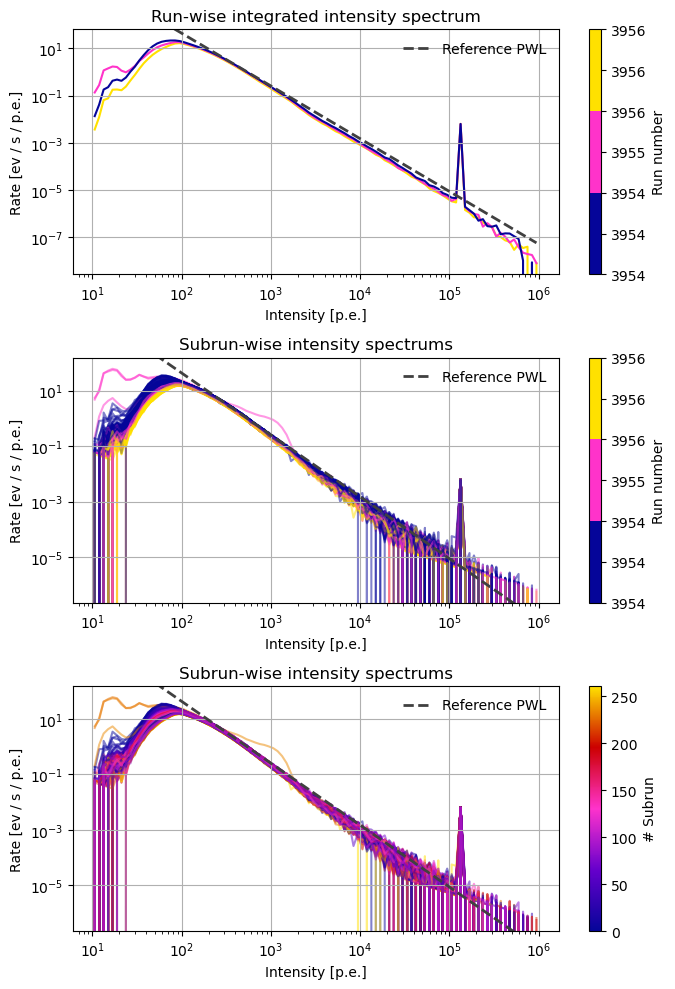

In [49]:
runs_total = range(len(dict_data["rates"]))
sruns_total = [
    np.arange(len(dict_data["rates"][i])) + 
    (offset := (offset + len(dict_data["rates"][i-1]) if i > 0 else 0)) for i in runs_total
]
_, colors_run = plotting.get_cmap_colors(runs_total, plotting.default_cmap)
colors_srun = [plotting.get_cmap_colors(s, plotting.default_cmap)[1] if len(s) > 0 else [] 
               for s in sruns_total]
  
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(7, 10))
 
for i in range(len(dict_data["rates"])):
    ax1.plot(bin_c, np.mean(dict_data["rates"][i], axis=0), c=colors_run[i], zorder=np.random.rand())
    for j in range(len(dict_data["rates"][i])):
        ax2.plot(bin_c, dict_data["rates"][i][j], c=colors_run[i], zorder=np.random.rand(), alpha=0.5)
        ax3.plot(bin_c, dict_data["rates"][i][j], c=colors_srun[i][j], zorder=np.random.rand(), alpha=0.5)

if len(obs_ids) > 1:
    disc_cmap = plotting.create_discrete_cmap_from_colors(len(obs_ids))
    ax1.set_title("Run-wise integrated intensity spectrum")
    plotting.plot_colorbar(fig, ax1, obs_ids, disc_cmap, "Run number", True, False)
    ax2.set_title("Subrun-wise intensity spectrums")
    plotting.plot_colorbar(fig, ax2, obs_ids, disc_cmap, "Run number", True, False)
ax3.set_title("Subrun-wise intensity spectrums")
plotting.plot_colorbar(fig, ax3, np.concatenate(sruns_total), plotting.default_cmap, "# Subrun")

x = bin_c
y = geom.powerlaw(x / ref_intensity, ref_p0, ref_p1)

for ax in [ax1, ax2, ax3]:
    ax.loglog()
    
    ylims = ax.get_ylim()
    ax.plot(x, y, c="0.25", ls="--", lw=2, label="Reference PWL")
    ax.set_ylim(ylims)
    
    ax.set_xlabel("Intensity [p.e.]"); ax.set_ylabel("Rate [ev / s / p.e.]")
    ax.grid(); ax.legend(loc=1, frameon=False)

fig.tight_layout()

plt.savefig(root + f"plots/plot_intensity_spectrums_{obs_ids[0]}.png", bbox_inches="tight", dpi=300)
plt.show()

## Plot of parameter evolution

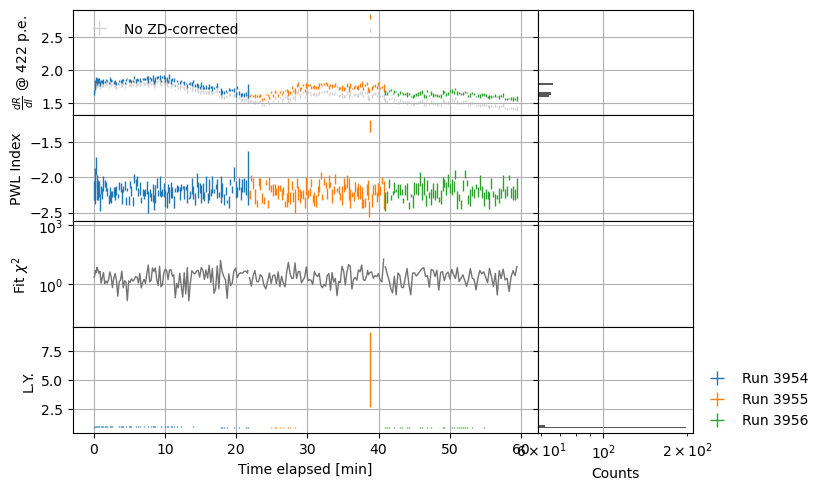

In [56]:
fig, ((ax1, ax1h), (ax2, ax2h), (ax3, ax3h), (ax4, ax4h)) = plt.subplots(
    4, 2, figsize=(8, 5.5), sharex="col", sharey="row", gridspec_kw={"width_ratios": [3, 1]})

t_offset = 0.0
data_1, data_2, data_3, data_4 = [], [], [], []
for r in range(len(dict_data["p0_c"])):
    ax1.errorbar(
        np.cumsum(dict_data["tspan"][r] / 60) + t_offset, dict_data["p0_c"][r], yerr=dict_data["u_p0_c"][r],
        ls="", marker="", lw=1, color=f"C{r}"
    ); data_1.extend(dict_data["p0_c"][r])    
    ax1.errorbar(
        np.cumsum(dict_data["tspan"][r] / 60) + t_offset, dict_data["p0"][r], yerr=dict_data["u_p0"][r],
        ls="", marker="", lw=1, color=f"lightgray", zorder=-10
    ); data_1.extend(dict_data["p0"][r])  
    ax2.errorbar(
        np.cumsum(dict_data["tspan"][r] / 60) + t_offset, dict_data["p1_c"][r], yerr=dict_data["u_p1_c"][r],
        ls="", marker="", lw=1, color=f"C{r}"
    ); data_2.extend(dict_data["p1_c"][r])
    ax3.errorbar(
        np.cumsum(dict_data["tspan"][r] / 60) + t_offset, dict_data["fit_chi2"][r], 
        ls="-", lw=1, color="0.45"
    ); data_3.extend(dict_data["fit_chi2"][r])
    ax4.errorbar(
        np.cumsum(dict_data["tspan"][r] / 60) + t_offset, dict_data["ly"][r], yerr=dict_data["u_ly"][r],
        ls="", lw=1, color=f"C{r}"
    ); data_4.extend(dict_data["ly"][r])
    ax4h.errorbar([], [], xerr=1, yerr=1, ls="", lw=1, color=f"C{r}", label=f"Run {obs_ids[r]}")
    
    t_offset += np.cumsum(dict_data["tspan"][r] / 60)[-1]

ax1h.hist(data_1, bins=np.linspace(np.percentile(data_1, perc), np.percentile(data_1, 100-perc), 40),
          orientation="horizontal", color="0.35")
ax2h.hist(data_2, bins=np.linspace(np.percentile(data_2, perc), np.percentile(data_2, 100-perc), 40),
          orientation="horizontal", color="0.35")
ax3h.hist(data_3, bins=np.logspace(np.log(np.min(data_3)), np.log(np.max(data_3)), 40), 
          orientation="horizontal", color="0.35") 
ax4h.hist(data_4, bins=np.linspace(np.percentile(data_4, perc), np.percentile(data_4, 100-perc), 40), 
          orientation="horizontal", color="0.35")    

# perc = 0.01
# ax1.set_ylim(np.percentile(data_1, perc), max(np.percentile(data_1, 100-perc), ref_p0 + 0.2))
# ax2.set_ylim(np.percentile(data_2, perc), max(np.percentile(data_2, 100-perc), ref_p1 + 0.2))
# ax3.set_ylim(np.min(data_3), np.max(data_3))
# ax4.set_ylim(np.percentile(data_4, perc), max(np.percentile(data_4, 99.5), 1.0 + 0.1))

# for ax in [ax1, ax1h]:
#     ax.axhline(ref_p0, ls="--", color="k")
# for ax in [ax2, ax2h]:    
#     ax.axhline(ref_p1, ls="--", color="k")
# for ax in [ax4, ax4h]:
#     ax.axhline(1, ls="--", color="k", label="Reference")

for ax in [ax1, ax1h, ax2, ax2h, ax3, ax3h, ax4, ax4h]:
    ax.grid()
    
ax1.errorbar([], [], xerr=1, yerr=1, ls="", lw=1, color=f"lightgray", label=f"No ZD-corrected")

ax4.set_xlabel("Time elapsed [min]"); ax4h.set_xlabel("Counts")
ax1.set_ylabel("$\\frac{dR}{dI}$ @ 422 p.e.")
ax2.set_ylabel("PWL Index"); ax3.set_ylabel("Fit $\chi^2$"); ax4.set_ylabel("L.Y.")
ax3.set_yscale("log")
ax1h.set_xscale("log")
ax1.legend(frameon=False); ax4h.legend(frameon=False, loc=(1.03, 0))
plt.subplots_adjust(wspace=0, hspace=0)

plt.savefig(root + f"plots/plot_intensity_parameters_runs_{obs_ids[0]}.png", bbox_inches="tight", dpi=300)
plt.show()

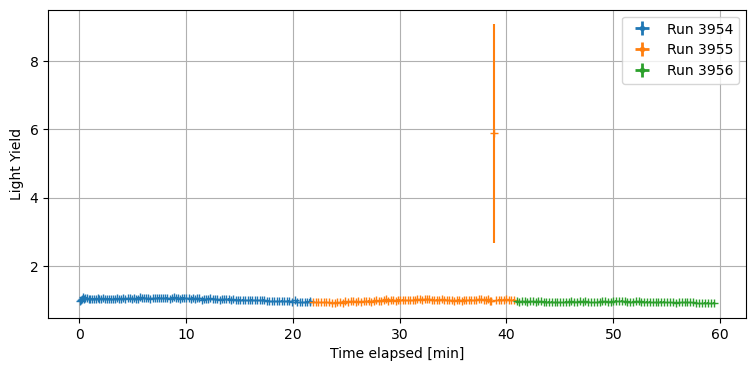

In [55]:
fig, ax = plt.subplots(figsize=(9, 4))

t_offset = 0.0
for r in range(len(dict_data["p0_c"])):

    ax.errorbar(
        np.cumsum(dict_data["tspan"][r] / 60) + t_offset, dict_data["ly"][r], yerr=dict_data["u_ly"][r],
        ls="", lw=1.5, color=f"C{r}", marker="+"
    ); data_4.extend(dict_data["ly"][r])
    ax.errorbar([], [], xerr=1, yerr=1, ls="", marker=".", lw=2, color=f"C{r}", label=f"Run {obs_ids[r]}")
    
#     ax.plot(np.cumsum(dict_data["tspan"][r] / 60) + t_offset, dict_data["ly"][r])    
    t_offset += np.cumsum(dict_data["tspan"][r] / 60)[-1]

ax.legend()
ax.grid()
ax.set_xlabel("Time elapsed [min]")
ax.set_ylabel("Light Yield")
# ax.set_ylim(0.8, 1.2)

# plt.savefig(root + f"plots/plot_zoom_light_yield_runs_{obs_ids[0]}.png", bbox_inches="tight", dpi=300)
plt.show()

## Plot Run-wise dRdI fit

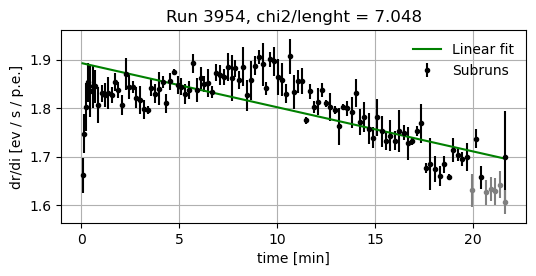

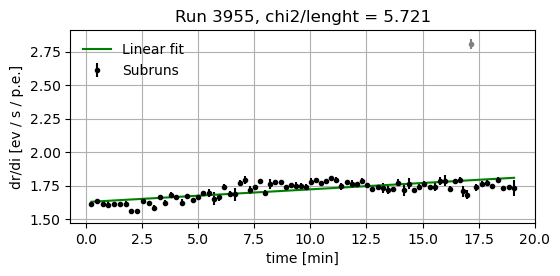

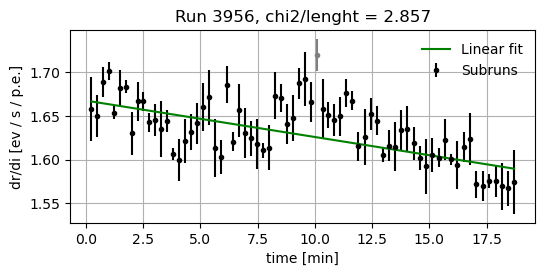

In [7]:
run_fit_p0, run_fit_p1, run_fit_delta_p0, run_fit_delta_p1 = [], [], [], []
run_fit_chi2, run_fit_pvalue, run_fit_ndf, run_fit_error_flag = [], [], [],[]
run_fit_mask = []

for i, obs_id in enumerate(obs_ids):
    x_fit, y_fit = np.cumsum(dict_data["tspan"][i]), np.array(dict_data["p0_c"][i])
    yerr_fit = np.array(dict_data["u_p0_c"][i])
    
    # Excluding NaN values
    mask_nan = (np.isnan(x_fit) | np.isnan(y_fit))
    # We will exclude too small error that will lead to wrong fit
    mask_zero_error = np.array([e < 1e-5 for e in yerr_fit])

    # Define the range within 2 standard deviations from the mean
    lower_bound = np.mean(y_fit) - 2 * np.std(y_fit)
    upper_bound = np.mean(y_fit) + 2 * np.std(y_fit)
    mask_lowhigh = ~((y_fit >= lower_bound) & (y_fit <= upper_bound))

    # Total mask
    mask_fit = ~(mask_nan | mask_zero_error | mask_lowhigh)
    run_fit_mask.append(mask_fit)
    
    if np.sum(mask_fit) > 2:
        params, pcov, info, _, _ = curve_fit(
            f     = geom.straight_line,
            xdata = x_fit[mask_fit],
            ydata = y_fit[mask_fit],
            sigma = yerr_fit[mask_fit],
            p0    = [0, 1],
            full_output = True,
        )

        run_fit_p0.append(params[0]); run_fit_p1.append(params[1])        
        run_fit_delta_p0.append(np.sqrt(pcov[0, 0])); run_fit_delta_p1.append(np.sqrt(pcov[1, 1]))
        fit_ndf = len(x_fit)
        fit_chi2 = np.sum(info["fvec"] ** 2)
        run_fit_chi2.append(fit_ndf); run_fit_ndf.append(fit_chi2)
        run_fit_pvalue.append(1 - chi2.cdf(fit_chi2, fit_ndf)) 
        run_fit_error_flag.append(False)
    else:
        run_fit_p0.append(np.nan); run_fit_p1.append(np.nan)        
        run_fit_delta_p0.append(np.nan); run_fit_delta_p1.append(np.nan)
        run_fit_chi2.append(np.nan); run_fit_ndf.append(np.nan)
        run_fit_pvalue.append(np.nan) 
        run_fit_error_flag.append(True)
        
    fig, ax = plt.subplots(figsize=(6,2.5))
    
    ax.errorbar(x_fit[mask_fit] / 60, y_fit[mask_fit], yerr=yerr_fit[mask_fit], 
                marker=".", color="k", ls="", label="Subruns")
    ax.plot(x_fit / 60, geom.straight_line(x_fit, run_fit_p0[i], run_fit_p1[i]), 
            color="r" if run_fit_error_flag[i] else "g", label="Linear fit")

    ax.errorbar(x_fit[~mask_fit] / 60, y_fit[~mask_fit], yerr=yerr_fit[~mask_fit], 
                marker=".", color="gray", ls="")

    ax.set_title(f"Run {obs_id}, chi2/lenght = {fit_chi2 / np.sum(mask_fit):.3f}")

    ax.set_xlabel("time [min]")
    ax.set_ylabel("dr/di [ev / s / p.e.]")
    ax.grid()
    ax.legend(frameon=False)
#     plt.savefig(f"plots/plot_runwise_drdi_fit_run{obs_id}.png", bbox_inches="tight", dpi=300)
    plt.show()

## Plot of LIDAR transmission example

In [8]:
df = pd.read_csv("../data/LIDAR/S241125n_data.csv")
df = df[df["T@3km"] != -1.0]

lidar_timestamps = Time(df["MJD"], format="mjd").to_datetime()
lidar_telapsed = [0, *np.array([t.total_seconds() for t in np.diff(lidar_timestamps)])]

lidar_zeniths = df["Zd"]
lidar_transmission3 = df["T@3km"]
lidar_transmission6 = df["T@6km"]
lidar_transmission9 = df["T@9km"]

lidar_transmission3 = lidar_transmission3 ** np.cos(np.deg2rad(lidar_zeniths))
lidar_transmission6 = lidar_transmission6 ** np.cos(np.deg2rad(lidar_zeniths))
lidar_transmission9 = lidar_transmission9 ** np.cos(np.deg2rad(lidar_zeniths))

lidar_offset = lidar_timestamps[0].timestamp() - np.min(np.concatenate(dict_data["tstamp"]))

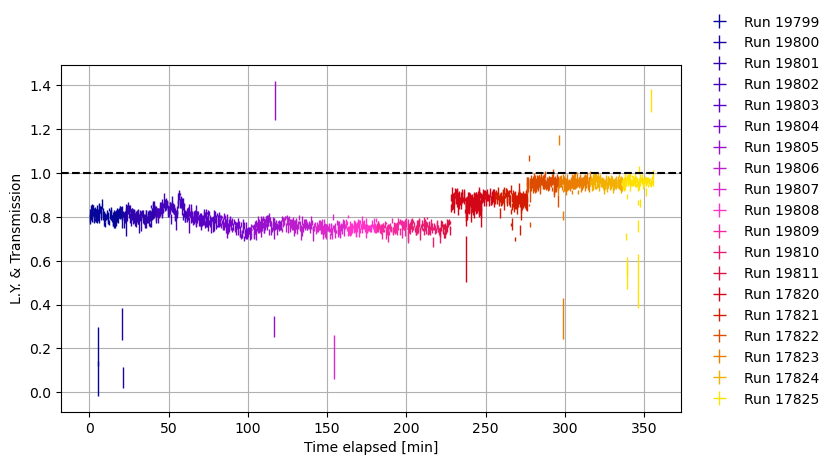

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))

t_offset = 0.0
for r in range(len(dict_data["p0_c"])):
    ax.errorbar(np.cumsum(dict_data["tspan"][r] / 60) + t_offset, dict_data["ly"][r], 
                yerr=dict_data["u_ly"][r], xerr=0,
                ls="", lw=1, color=colors_run[r], label=f"Run {obs_ids[r]}")
    t_offset += np.cumsum(dict_data["tspan"][r] / 60)[-1]
ax.axhline(1, ls="--", color="k")

# labels = ["T(3km)", "T(6km)", "T(9km)"]
# transmissions = [lidar_transmission3, lidar_transmission6, lidar_transmission9]
# x_values = np.cumsum(lidar_telapsed) / 60 + lidar_offset / 60
# for color, label, transmission in zip(["c", "dodgerblue", "b"], labels, transmissions):
#     ax.plot(x_values, transmission, "-", mew=1.5, ms=6, c=color, label=label)
#     ax.errorbar(x_values, transmission, xerr=3, ls="", mew=1.5, ms=6, c=color, label=label)

ax.set_xlabel("Time elapsed [min]"); ax.set_ylabel("L.Y. & Transmission")
ax.grid(); ax.legend(loc=(1.03, 0), frameon=False)

plt.savefig(root + f"plots/plot_LIDAR_data comparison.png", bbox_inches="tight", dpi=300)
plt.show()